# Offline RL Training with Visuals
This notebook trains Behavioral Cloning and Tabular Q-Learning models directly on the static offline CSV datasets extracted previously. It includes visual graphs (`seaborn` and `matplotlib`) to help interpret the agent's learned policies and demonstrate the class-imbalance baseline.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Actions mapping for printing
ACTIONS = {
    0: "Ask Info", 
    1: "Provide Solution", 
    2: "Affective Repair", 
    3: "Escalate", 
    4: "Close", 
    5: "Proactive Update", 
    6: "Set Expectation"
}
SENTIMENTS = {0: "Angry", 1: "Neutral", 2: "Happy"}


## 1. Tabular Q-Learning Implementation

In [9]:
def train_offline_q_learning(csv_path, alpha=0.1, gamma=0.99, epochs=50):
    """
    Trains a Tabular Q-Learning agent directly on static dataset transitions.
    """
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Dataset not found: {csv_path}")
        return None
        
    if df.empty:
        return None
        
    Q = np.zeros((3, 7))
    transitions = df[['state', 'action', 'reward', 'next_state', 'done']].values
    
    print(f"Training Tabular Q-Learning on {len(transitions)} transitions from {csv_path}...")
    
    for epoch in range(epochs):
        np.random.shuffle(transitions)
        for t in transitions:
            s, a, r, s_next, done = int(t[0]), int(t[1]), t[2], int(t[3]), t[4]
            td_target = r if done else r + gamma * np.max(Q[s_next])
            td_error = td_target - Q[s, a]
            Q[s, a] += alpha * td_error
            
    return Q


## 2. Behavioral Cloning Implementation

In [10]:
def train_behavioral_cloning(csv_path):
    """
    Supervised learning approach: maps states to the most frequent expert actions.
    """
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        return None
        
    print(f"Training Behavioral Cloning (BC) on {len(df)} transitions...")
    counts = np.zeros((3, 7))
    for _, row in df.iterrows():
        counts[int(row['state']), int(row['action'])] += 1
        
    bc_policy = np.zeros(3, dtype=int)
    for s in range(3):
        if np.sum(counts[s]) > 0:
            bc_policy[s] = np.argmax(counts[s])
        else:
            bc_policy[s] = 1 
            
    return bc_policy


## 3. Evaluation & Visualization Functions \nIncludes raw printouts and `matplotlib`/`seaborn` graphs.

In [11]:
def evaluate_q_policy(Q, dataset_name):
    print(f"\n--- Optimal Q-Learning Policy for {dataset_name} ---")
    for s in range(3):
        best_a = np.argmax(Q[s])
        print(f"If Customer is [ {SENTIMENTS[s]:<7} ], Agent should -> {ACTIONS[best_a]}")

def evaluate_bc_policy(bc_policy, dataset_name):
    print(f"\n--- Behavioral Cloning Policy for {dataset_name} ---")
    for s in range(3):
        print(f"If Customer is [ {SENTIMENTS[s]:<7} ], Most frequent action was -> {ACTIONS[bc_policy[s]]}")

def plot_q_values(Q, dataset_name):
    plt.figure(figsize=(10, 4))
    sns.heatmap(Q, annot=True, fmt=".2f", cmap="coolwarm", 
                xticklabels=[ACTIONS[i] for i in range(7)],
                yticklabels=[SENTIMENTS[i] for i in range(3)])
    plt.title(f"{dataset_name} - Q-Learning Action Values (Higher is Better)")
    plt.xlabel("Agent Actions")
    plt.ylabel("Customer Sentiment State")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_action_distribution(csv_path, dataset_name):
    try:
        df = pd.read_csv(csv_path)
    except:
        return
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x='action', palette="Set2", hue='action', legend=False)
    plt.title(f"{dataset_name} - True Action Frequency (Explains BC Bias)")
    plt.xticks(ticks=range(7), labels=[ACTIONS[i] for i in range(7)], rotation=45, ha='right')
    plt.ylabel("Total Count")
    plt.xlabel("Agent Actions")
    plt.tight_layout()
    plt.show()


## 4. Run Training Sequence \nThis executes the full Offline RL and Supervised algorithms natively on the CSV offline transitions.


 Processing Twitter Dataset
Training Tabular Q-Learning on 9179 transitions from offline_dataset_twitter.csv...

--- Optimal Q-Learning Policy for Twitter ---
If Customer is [ Angry   ], Agent should -> Provide Solution
If Customer is [ Neutral ], Agent should -> Close
If Customer is [ Happy   ], Agent should -> Set Expectation


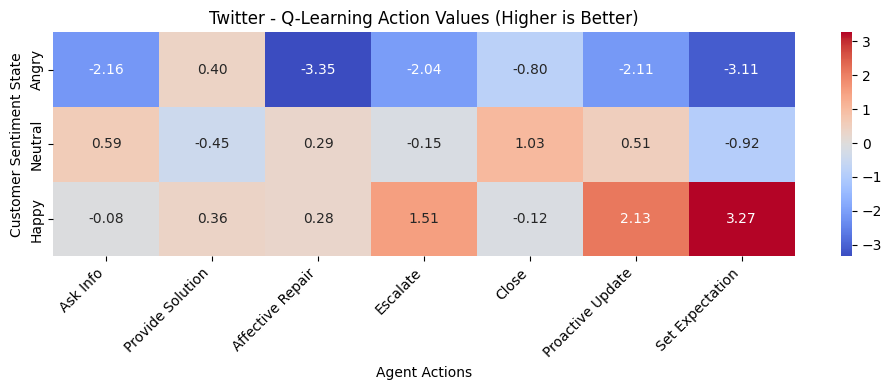

Training Behavioral Cloning (BC) on 9179 transitions...

--- Behavioral Cloning Policy for Twitter ---
If Customer is [ Angry   ], Most frequent action was -> Provide Solution
If Customer is [ Neutral ], Most frequent action was -> Provide Solution
If Customer is [ Happy   ], Most frequent action was -> Provide Solution


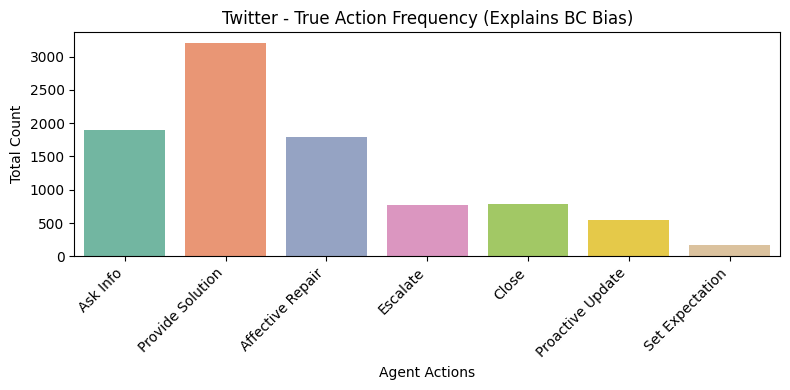


 Processing Reddit Dataset
Training Tabular Q-Learning on 8067892 transitions from offline_dataset_reddit.csv...

--- Optimal Q-Learning Policy for Reddit ---
If Customer is [ Angry   ], Agent should -> Set Expectation
If Customer is [ Neutral ], Agent should -> Proactive Update
If Customer is [ Happy   ], Agent should -> Set Expectation


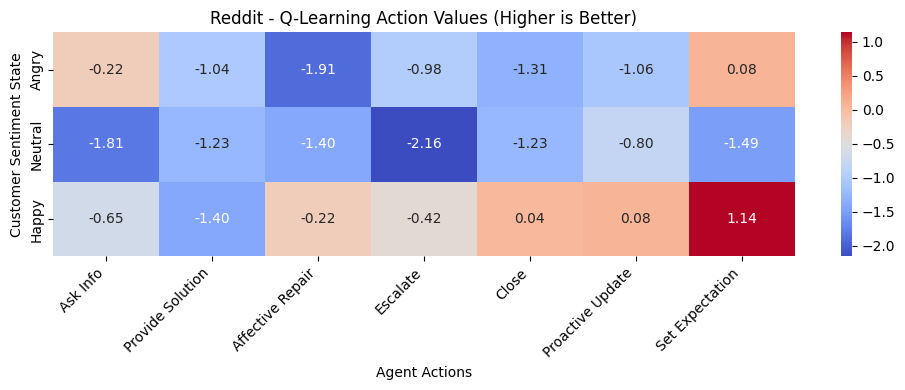

Training Behavioral Cloning (BC) on 8067892 transitions...

--- Behavioral Cloning Policy for Reddit ---
If Customer is [ Angry   ], Most frequent action was -> Provide Solution
If Customer is [ Neutral ], Most frequent action was -> Provide Solution
If Customer is [ Happy   ], Most frequent action was -> Provide Solution


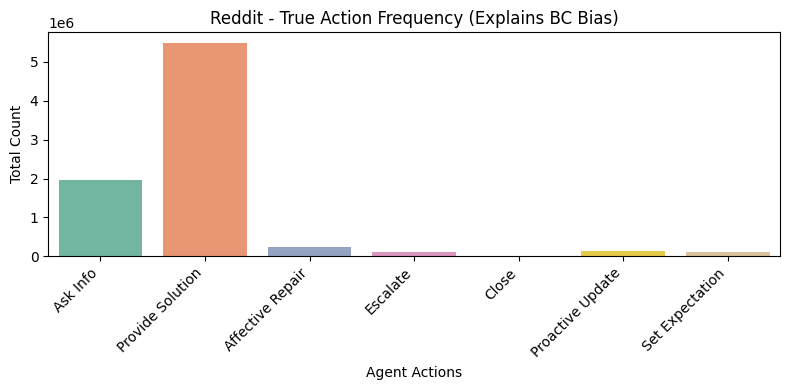


 Processing OpenAssistant Dataset
Training Tabular Q-Learning on 4352 transitions from offline_dataset_oasst.csv...

--- Optimal Q-Learning Policy for OpenAssistant ---
If Customer is [ Angry   ], Agent should -> Ask Info
If Customer is [ Neutral ], Agent should -> Set Expectation
If Customer is [ Happy   ], Agent should -> Affective Repair


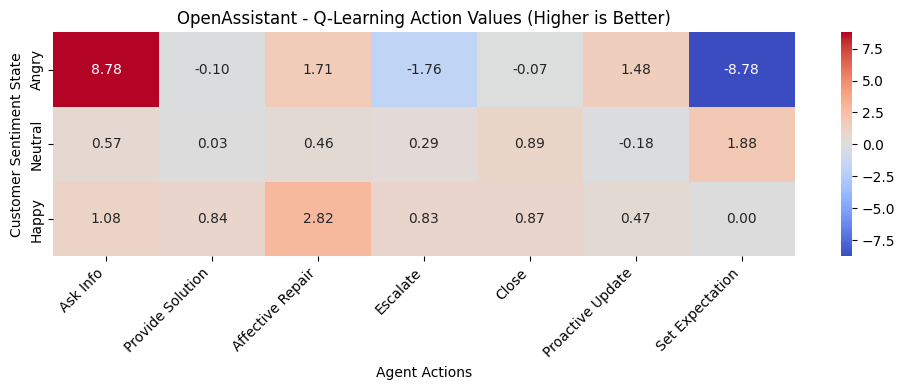

Training Behavioral Cloning (BC) on 4352 transitions...

--- Behavioral Cloning Policy for OpenAssistant ---
If Customer is [ Angry   ], Most frequent action was -> Provide Solution
If Customer is [ Neutral ], Most frequent action was -> Provide Solution
If Customer is [ Happy   ], Most frequent action was -> Provide Solution


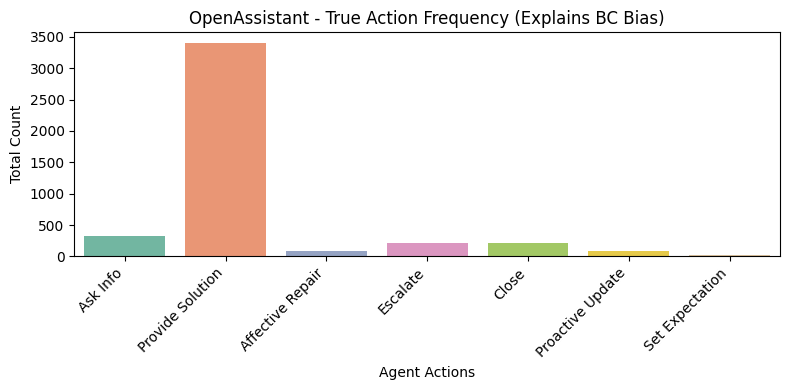

In [12]:
datasets = [
    ("Twitter", "offline_dataset_twitter.csv"), 
    ("Reddit", "offline_dataset_reddit.csv"), 
    ("OpenAssistant", "offline_dataset_oasst.csv")
]

for name, path in datasets:
    print(f"\n{'='*50}\n Processing {name} Dataset\n{'='*50}")
    
    # 1. Tabular Q-Learning Model & Heatmap
    Q = train_offline_q_learning(path, epochs=20) 
    if Q is not None:
        evaluate_q_policy(Q, name)
        plot_q_values(Q, name)
        
    # 2. Behavioral Cloning Model & Distribution Bar Chart
    bc_policy = train_behavioral_cloning(path)
    if bc_policy is not None:
        evaluate_bc_policy(bc_policy, name)
        plot_action_distribution(path, name)
